In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp



In [8]:
##Golden Solution
x, y = sp.symbols('x y')

f = sp.exp(x**2 + y**2) - 4*x

# Partielle Ableitungen
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
print("df/dx =", df_dx)
print("df/dy =", df_dy)

# Gleichungssystem lösen
optimum = sp.solve([df_dx, df_dy], [x, y])
print("Optimum bei:", optimum)





df/dx = 2*x*exp(x**2 + y**2) - 4
df/dy = 2*y*exp(x**2 + y**2)
Optimum bei: [(2*exp(-LambertW(8)/2), 0)]


In [11]:
# Newton Methode braucht Ableitungen/ Gradient und Hesse
# Ableitungen
f_dx = sp.diff(f, x)
f_dy = sp.diff(f, y)
f_dxx = sp.diff(f_dx, x)
f_dyy = sp.diff(f_dy, y)
f_dxy = sp.diff(f_dx, y)

print("f(x,y) =", f)
print("∂f/∂x =", f_dx)
print("∂f/∂y =", f_dy)

# Hessian Matrix
H = sp.Matrix([
    [f_dxx, f_dxy],
    [f_dxy, f_dyy]
])

# Gradient
grad = sp.Matrix([f_dx, f_dy])

# Newton Methode
x_n = sp.Matrix([sp.Float(2.0), sp.Float(2.0)]) 
path = [x_n.T.tolist()[0]]

for i in range(100):
    grad_val = grad.subs([(x, x_n[0]), (y, x_n[1])])
    H_val = H.subs([(x, x_n[0]), (y, x_n[1])])
    
    x_n = x_n - H_val.inv() * grad_val
    path.append(x_n.T.tolist()[0])
    
    f_val = f.subs([(x, x_n[0]), (y, x_n[1])])
    print(f"Iteration {i+1}: x = {float(x_n[0]):.6f}, y = {float(x_n[1]):.6f}, f = {float(f_val):.6f}")

print(f"\nOptimum bei x = {float(x_n[0]):.4f}, y = {float(x_n[1]):.4f}")

#KOnstante Hesse -> Optimum wird sofort gefunden bei quadratischen Funktionen
print("\nHessian =", H)


f(x,y) = -4*x + exp(x**2 + y**2)
∂f/∂x = 2*x*exp(x**2 + y**2) - 4
∂f/∂y = 2*y*exp(x**2 + y**2)
Iteration 1: x = 1.882708, y = 1.882037, f = 1188.368780
Iteration 2: x = 1.759519, y = 1.757220, f = 477.758382
Iteration 3: x = 1.630106, y = 1.623857, f = 192.649253
Iteration 4: x = 1.494875, y = 1.479140, f = 77.325324
Iteration 5: x = 1.356143, y = 1.318113, f = 30.325333
Iteration 6: x = 1.220514, y = 1.131912, f = 11.090595
Iteration 7: x = 1.102129, y = 0.905997, f = 3.247700
Iteration 8: x = 1.020871, y = 0.624461, f = 0.104123
Iteration 9: x = 0.976674, y = 0.305281, f = -1.057353
Iteration 10: x = 0.930159, y = 0.071342, f = -1.333044
Iteration 11: x = 0.899520, y = 0.004744, f = -1.352062
Iteration 12: x = 0.896077, y = 0.000030, f = -1.352183
Iteration 13: x = 0.896050, y = 0.000000, f = -1.352183
Iteration 14: x = 0.896050, y = 0.000000, f = -1.352183
Iteration 15: x = 0.896050, y = 0.000000, f = -1.352183
Iteration 16: x = 0.896050, y = 0.000000, f = -1.352183
Iteration 17: x 

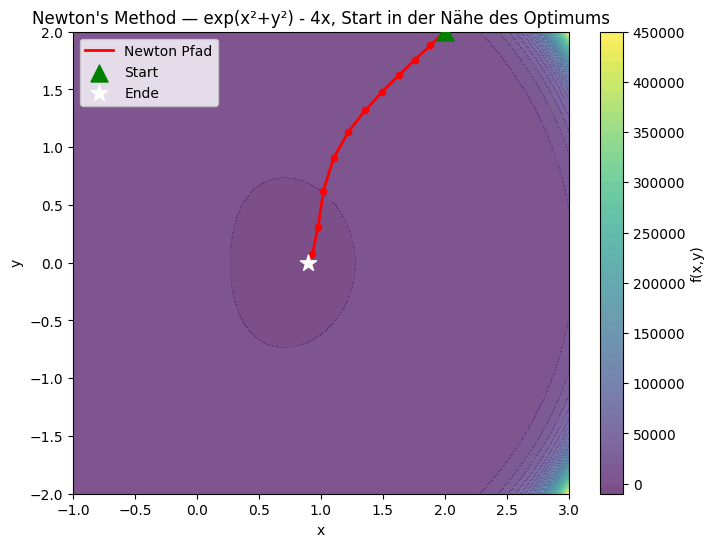

In [15]:
# Path in numpy arrays umwandeln
path_np = np.array([(float(p[0]), float(p[1])) for p in path])

# Hintergrund: Konturplot der Funktion
x_grid = np.linspace(-1, 3, 300)
y_grid = np.linspace(-2, 2, 300)
X, Y = np.meshgrid(x_grid, y_grid)

Z = np.exp(X**2 + Y**2) - 4*X

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
plt.colorbar(label='f(x,y)')
plt.contour(X, Y, Z, levels=50, colors='white', linewidths=0.3, alpha=0.4)

# Pfad plotten
plt.plot(path_np[:, 0], path_np[:, 1], color='red', lw=2, label='Newton Pfad')
plt.scatter(path_np[:, 0], path_np[:, 1], color='red', s=20, zorder=5)
plt.scatter(path_np[0, 0], path_np[0, 1], color='green', s=150, marker='^', zorder=6, label='Start')
plt.scatter(path_np[-1, 0], path_np[-1, 1], color='white', s=150, marker='*', zorder=6, label='Ende')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Newton's Method — exp(x²+y²) - 4x, Start in der Nähe des Optimums")
plt.legend()
plt.show()


##Line Search ist wichtig